# L'Arene des Algos - Jour 3 (le Fight des IA)

**Auteur : Mohammed MOSLEH**

Aujourd'hui on attaque 4 problemes reels, chacun d'une famille differente, puis le
grand combat : le **Fight des IA**. A la fin, un leaderboard d'algos compares, et on
sait justifier son champion (pas juste "il a le meilleur score", mais "voici le bon
score a regarder vu le probleme"). C'est, en miniature, exactement ce qu'on fait sur Kaggle.

- **Phase A** - Prix immobiliers (regression)
- **Phase B** - Segmenter des annonces Airbnb (non supervise / clustering)
- **Phase C** - Courriel vs spam (classification de texte)
- **Phase D** - Signaux sonar : mine ou rocher ? (classification binaire)
- **Phase E** - Le Fight des IA (leaderboard)

## Phase 0 : Mise en route

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score, recall_score,
                             classification_report, silhouette_score)

RANDOM_STATE = 42
print("Imports OK.")

Imports OK.


## Phase A : Predire les prix immobiliers (regression)

Estimer le prix median d'un logement en Californie a partir du revenu median du quartier,
l'age des logements, la population... C'est de la **regression** (on predit un nombre).
On compare une regression lineaire (baseline lisible) a un Random Forest, avec les 3
metriques de regression : R2, MAE, RMSE.

(On n'utilise PAS Boston Housing, retire pour des biais ethiques.)

In [2]:
from sklearn.datasets import fetch_california_housing

def charger_immobilier():
    """Charge California Housing, renvoie X, y."""
    data = fetch_california_housing()
    print("California Housing :", data.data.shape, "variables, cible = prix median en centaines de milliers de $")
    print("Variables :", list(data.feature_names))
    return data.data, data.target

def evaluer_regression(modele, X_train, X_test, y_train, y_test):
    """Entraine, predit, renvoie {r2, mae, rmse}."""
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"r2": r2_score(y_test, y_pred),
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": rmse}

X, y = charger_immobilier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Standardisation (le scaler s'ajuste sur le train seul - reflexe J2)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

for nom, mod in {"LinearRegression": LinearRegression(),
                 "RandomForest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)}.items():
    r = evaluer_regression(mod, X_train_s, X_test_s, y_train, y_test)
    print(f"{nom:<17}: R2={r['r2']:.2f}  MAE={r['mae']:.2f}  RMSE={r['rmse']:.2f}")

California Housing : (20640, 8) variables, cible = prix median en centaines de milliers de $
Variables : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
LinearRegression : R2=0.58  MAE=0.53  RMSE=0.75


RandomForest     : R2=0.81  MAE=0.33  RMSE=0.51


### Checkpoint qualite

In [3]:
# Cas limite : entrainer sur seulement 100 lignes -> le R2 s'effondre (un modele a besoin de donnees)
petit = evaluer_regression(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
                           X_train_s[:100], X_test_s, y_train[:100], y_test)
print(f"RandomForest sur 100 lignes : R2={petit['r2']:.2f}  (vs ~0.80 sur tout) -> le manque de donnees fait chuter le modele")

# Cas adversarial : un quartier fictif aberrant (revenu median 0, 9000 habitants)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(X_train_s, y_train)
fictif = X_train.mean(axis=0).copy()
fictif[0] = 0      # MedInc = 0
fictif[4] = 9000   # Population = 9000
pred = rf.predict(scaler.transform([fictif]))[0]
print(f"Prix predit pour le quartier fictif : {pred:.2f} (x100k$)")
print("En prod, ces entrees hors plage devraient etre detectees et rejetees en amont (validation des entrees).")

RandomForest sur 100 lignes : R2=0.54  (vs ~0.80 sur tout) -> le manque de donnees fait chuter le modele


Prix predit pour le quartier fictif : 0.64 (x100k$)
En prod, ces entrees hors plage devraient etre detectees et rejetees en amont (validation des entrees).


## Phase B : Segmenter des annonces Airbnb (non supervise)

Airbnb veut regrouper ses annonces en segments naturels (premium, budget, familial...)
**sans aucune etiquette**. C'est du clustering (KMeans). On garde quelques colonnes
numeriques, on nettoie, on **standardise** (obligatoire avant KMeans), puis on cherche
le bon nombre de segments via l'inertie (coude) et le score de silhouette.

In [4]:
def charger_airbnb(chemin_csv):
    """Charge le CSV, garde les colonnes numeriques utiles, nettoie les NaN."""
    df = pd.read_csv(chemin_csv)
    cols = ["price", "minimum_nights", "number_of_reviews", "availability_365"]
    df = df[cols].dropna()
    print(f"Listings charges : {len(df)} lignes, {df.shape[1]} colonnes numeriques retenues")
    return df

def choisir_k(X_scaled, k_range=range(2, 9)):
    """Pour chaque k : inertie et silhouette."""
    resultats = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
        sil = silhouette_score(X_scaled, km.labels_)
        resultats.append((k, km.inertia_, sil))
        print(f"k={k} : inertie={km.inertia_:.0f}  silhouette={sil:.3f}")
    meilleur = max(resultats, key=lambda r: r[2])[0]
    print(f"\nSegment retenu (meilleure silhouette) : k={meilleur}")
    return resultats, meilleur

df_bnb = charger_airbnb("airbnb_listings.csv")
X_bnb = StandardScaler().fit_transform(df_bnb)
res, k_opt = choisir_k(X_bnb)

Listings charges : 8000 lignes, 4 colonnes numeriques retenues


k=2 : inertie=24511  silhouette=0.778


k=3 : inertie=18384  silhouette=0.410


k=4 : inertie=13612  silhouette=0.421


k=5 : inertie=8897  silhouette=0.460


k=6 : inertie=7459  silhouette=0.471


k=7 : inertie=6203  silhouette=0.477


k=8 : inertie=5332  silhouette=0.363

Segment retenu (meilleure silhouette) : k=2


In [5]:
# Description rapide des segments trouves
km = KMeans(n_clusters=k_opt, n_init=10, random_state=RANDOM_STATE).fit(X_bnb)
df_bnb = df_bnb.copy()
df_bnb["segment"] = km.labels_
print("Profil moyen par segment :")
print(df_bnb.groupby("segment").mean().round(1).to_string())

Profil moyen par segment :
         price  minimum_nights  number_of_reviews  availability_365
segment                                                            
0        263.5             6.4               25.2             181.0
1        163.5           361.8               14.7             333.2


### Ce qui doit casser

In [6]:
# Cas limite : KMeans SANS standardiser -> la colonne 'price' (grande echelle) ecrase tout
km_brut = KMeans(n_clusters=k_opt, n_init=10, random_state=RANDOM_STATE).fit(df_bnb[["price","minimum_nights","number_of_reviews","availability_365"]])
sil_brut = silhouette_score(df_bnb[["price","minimum_nights","number_of_reviews","availability_365"]], km_brut.labels_)
sil_scaled = silhouette_score(X_bnb, km.labels_)
print(f"Silhouette SANS scaling : {sil_brut:.3f}  |  AVEC scaling : {sil_scaled:.3f}")
print("Sans scaling, la variable 'price' domine la distance -> segments moins propres.")

# Cas adversarial : une annonce a 100 000 la nuit (outlier non nettoye)
df_pollue = df_bnb.copy()
df_pollue.loc[df_pollue.index[0], "price"] = 100000
X_pollue = StandardScaler().fit_transform(df_pollue[["price","minimum_nights","number_of_reviews","availability_365"]])
km_p = KMeans(n_clusters=k_opt, n_init=10, random_state=RANDOM_STATE).fit(X_pollue)
print(f"\nAvec 1 annonce a 100000/nuit : tailles des clusters = {np.bincount(km_p.labels_)}")
print("Un seul outlier deplace les centres et peut creer un cluster a lui tout seul.")
print("-> le nettoyage J2 (outliers) est un prerequis absolu avant KMeans.")

Silhouette SANS scaling : 0.950  |  AVEC scaling : 0.778
Sans scaling, la variable 'price' domine la distance -> segments moins propres.

Avec 1 annonce a 100000/nuit : tailles des clusters = [7881  119]
Un seul outlier deplace les centres et peut creer un cluster a lui tout seul.
-> le nettoyage J2 (outliers) est un prerequis absolu avant KMeans.


## Phase C : Courriel vs spam (texte)

Classer des SMS en spam ou normal. Terrain de chasse de **Naive Bayes**. On vectorise le
texte avec TF-IDF (pondere chaque mot par sa rarete), on compare Naive Bayes a une
regression logistique. Les classes sont desequilibrees -> l'accuracy seule ment, on
regarde **precision / recall / f1** de la classe spam.

In [7]:
def vectoriser_textes(messages, vectorizer=None):
    """Transforme des textes en matrice numerique. Cree le vectorizer si None (fit), sinon transform."""
    if vectorizer is None:
        vectorizer = TfidfVectorizer(stop_words="english")
        X = vectorizer.fit_transform(messages)
    else:
        X = vectorizer.transform(messages)
    return X, vectorizer

def evaluer_spam(modele, X_train, X_test, y_train, y_test):
    """Entraine, predit, affiche le classification_report (pas juste l'accuracy)."""
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["normal", "spam"]))
    return y_pred

sms = pd.read_csv("sms_spam.tsv", sep="\t", header=None, names=["label", "message"])
y_sms = (sms["label"] == "spam").astype(int)

# On vectorise sur le TRAIN seul puis on applique au test (pas de fuite)
msg_train, msg_test, y_tr, y_te = train_test_split(
    sms["message"], y_sms, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sms)
X_tr, vect = vectoriser_textes(msg_train)
X_te, _ = vectoriser_textes(msg_test, vect)

print("=== Naive Bayes ===")
evaluer_spam(MultinomialNB(), X_tr, X_te, y_tr, y_te)
print("=== Regression logistique ===")
evaluer_spam(LogisticRegression(max_iter=1000), X_tr, X_te, y_tr, y_te)

=== Naive Bayes ===
              precision    recall  f1-score   support

      normal       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

=== Regression logistique ===


              precision    recall  f1-score   support

      normal       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



array([0, 0, 0, ..., 0, 0, 0], shape=(1115,))

### Trois scenarios

In [8]:
nb = MultinomialNB().fit(X_tr, y_tr)

# Edge case : un message vide ""
X_vide, _ = vectoriser_textes([""], vect)
print("Message vide -> predit :", "spam" if nb.predict(X_vide)[0] else "normal", "(le vectorizer ne plante pas, vecteur nul)")

# Adversarial : un spam deguise en message normal
piege = ["salut, ton colis t attend, confirme ici"]
X_piege, _ = vectoriser_textes(piege, vect)
print("Spam deguise -> predit :", "spam" if nb.predict(X_piege)[0] else "normal")
print("Note : sur du spam, precision ET recall comptent. Rater un vrai mail (faux positif)")
print("est souvent pire que laisser passer un spam.")

Message vide -> predit : normal (le vectorizer ne plante pas, vecteur nul)
Spam deguise -> predit : normal
Note : sur du spam, precision ET recall comptent. Rater un vrai mail (faux positif)
est souvent pire que laisser passer un spam.


## Phase D : Decrypter les signaux d'un sonar (classification binaire)

Un sous-marin envoie un signal sonar et recoit un echo : mine ou rocher ? 60 mesures de
frequence par echo, 208 lignes. Peu de lignes, beaucoup de variables : terrain ideal du
**SVM**. On standardise puis on compare logistique, SVM rbf et Random Forest.

In [9]:
def charger_sonar(chemin):
    """Charge le sonar, separe X (60 colonnes) et y (mine=1, rock=0).
    Ce CSV a un en-tete V1..V60 + Class deja codee en 1 (mine) / 0 (rocher).
    """
    df = pd.read_csv(chemin)
    X = df.iloc[:, :60].values
    y = df["Class"].astype(int).values
    print(f"Sonar : {X.shape}, mines={int(y.sum())}, rochers={int((y==0).sum())}")
    return X, y

Xs, ys = charger_sonar("sonar.csv")
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.25, random_state=RANDOM_STATE, stratify=ys)

sc = StandardScaler().fit(Xs_tr)
Xs_tr_s, Xs_te_s = sc.transform(Xs_tr), sc.transform(Xs_te)

for nom, mod in {"LogisticRegression": LogisticRegression(max_iter=5000),
                 "SVC (rbf)": SVC(kernel="rbf"),
                 "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)}.items():
    mod.fit(Xs_tr_s, ys_tr)
    acc = accuracy_score(ys_te, mod.predict(Xs_te_s))
    print(f"{nom:<19}: accuracy={acc:.2f}")

Sonar : (208, 60), mines=97, rochers=111
LogisticRegression : accuracy=0.83
SVC (rbf)          : accuracy=0.85
RandomForest       : accuracy=0.87


### Ce qui ne doit pas passer inapercu

In [10]:
# Cas limite : SANS standardiser -> SVM et logistique souffrent, le Random Forest beaucoup moins
print("Sans standardisation :")
for nom, mod in {"LogisticRegression": LogisticRegression(max_iter=5000),
                 "SVC (rbf)": SVC(kernel="rbf"),
                 "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)}.items():
    mod.fit(Xs_tr, ys_tr)
    acc = accuracy_score(ys_te, mod.predict(Xs_te))
    print(f"  {nom:<19}: accuracy={acc:.2f}")
print("Ici l'ecart est faible : les mesures sonar sont deja toutes entre 0 et 1.")
print("Sur une donnee aux echelles tres differentes, SVM/logistique chuteraient sans")
print("standardisation, alors que les arbres (Random Forest) s'en moquent.")

# Cas adversarial : un echo 100% a zero (capteur en panne)
svc = SVC(kernel="rbf").fit(Xs_tr_s, ys_tr)
echo_mort = np.zeros((1, 60))
print(f"\nEcho tout a zero (capteur HS) -> predit : {'mine' if svc.predict(sc.transform(echo_mort))[0] else 'rocher'}")
print("Le modele predit quand meme une classe avec assurance. En vrai, il faudrait detecter")
print("ce signal degenere EN AMONT et ne pas se fier a la prediction.")

Sans standardisation :
  LogisticRegression : accuracy=0.83
  SVC (rbf)          : accuracy=0.85


  RandomForest       : accuracy=0.87
Ici l'ecart est faible : les mesures sonar sont deja toutes entre 0 et 1.
Sur une donnee aux echelles tres differentes, SVM/logistique chuteraient sans
standardisation, alors que les arbres (Random Forest) s'en moquent.

Echo tout a zero (capteur HS) -> predit : mine
Le modele predit quand meme une classe avec assurance. En vrai, il faudrait detecter
ce signal degenere EN AMONT et ne pas se fier a la prediction.


## Phase E : Le Fight des IA (leaderboard)

Le grand combat. UN dataset (le sonar), UN seul decoupage (meme random_state pour tous),
UNE metrique adaptee (F1, car les deux classes comptent). Tous les algos pertinents
s'affrontent, et on sort un leaderboard trie qui affiche **le score ET le temps
d'entrainement**. Le champion n'est pas forcement le meilleur score : un modele 0.2%
meilleur mais 40x plus lent ne vaut peut-etre pas le coup en prod.

In [11]:
def fight_des_ia(X_train, X_test, y_train, y_test, metrique, nom_jeu="sonar", nom_metrique="F1"):
    """Entraine tous les algos sur le MEME split, renvoie un classement trie (score + temps)."""
    competiteurs = {
        "LogisticRegression": LogisticRegression(max_iter=5000),
        "DecisionTree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
        "SVC_rbf":            SVC(kernel="rbf"),
    }
    resultats = []
    for nom, mod in competiteurs.items():
        t0 = time.perf_counter()
        mod.fit(X_train, y_train)
        duree = time.perf_counter() - t0
        score = metrique(y_test, mod.predict(X_test))
        resultats.append((nom, score, duree))

    resultats.sort(key=lambda r: r[1], reverse=True)
    print(f"=== LEADERBOARD (jeu : {nom_jeu}, metrique : {nom_metrique}) ===")
    for rang, (nom, score, duree) in enumerate(resultats, 1):
        print(f"{rang}. {nom:<19}: {nom_metrique}={score:.2f}  ({duree:.2f}s)")
    return resultats

leaderboard = fight_des_ia(Xs_tr_s, Xs_te_s, ys_tr, ys_te, f1_score)

=== LEADERBOARD (jeu : sonar, metrique : F1) ===
1. RandomForest       : F1=0.83  (0.14s)
2. GradientBoosting   : F1=0.83  (0.13s)
3. SVC_rbf            : F1=0.81  (0.00s)
4. LogisticRegression : F1=0.80  (0.01s)
5. DecisionTree       : F1=0.71  (0.00s)


### Pour creuser : la metrique change-t-elle le champion ?

In [12]:
# Memes algos, metrique = accuracy puis recall : le podium bouge-t-il ?
print(">>> Avec accuracy :")
fight_des_ia(Xs_tr_s, Xs_te_s, ys_tr, ys_te, accuracy_score, nom_metrique="accuracy")
print("\n>>> Avec recall (mines reperees) :")
fight_des_ia(Xs_tr_s, Xs_te_s, ys_tr, ys_te, recall_score, nom_metrique="recall")

>>> Avec accuracy :


=== LEADERBOARD (jeu : sonar, metrique : accuracy) ===
1. RandomForest       : accuracy=0.87  (0.15s)
2. GradientBoosting   : accuracy=0.87  (0.16s)
3. SVC_rbf            : accuracy=0.85  (0.00s)
4. LogisticRegression : accuracy=0.83  (0.01s)
5. DecisionTree       : accuracy=0.75  (0.00s)

>>> Avec recall (mines reperees) :


=== LEADERBOARD (jeu : sonar, metrique : recall) ===
1. LogisticRegression : recall=0.75  (0.00s)
2. RandomForest       : recall=0.71  (0.18s)
3. GradientBoosting   : recall=0.71  (0.21s)
4. SVC_rbf            : recall=0.71  (0.00s)
5. DecisionTree       : recall=0.67  (0.00s)


[('LogisticRegression', 0.75, 0.0045618999865837395),
 ('RandomForest', 0.7083333333333334, 0.18062420000205748),
 ('GradientBoosting', 0.7083333333333334, 0.2059618999774102),
 ('SVC_rbf', 0.7083333333333334, 0.0011286000080872327),
 ('DecisionTree', 0.6666666666666666, 0.0019685000006575137)]

### Tuning du champion avec GridSearchCV

In [13]:
# On tune le SVM rbf (souvent champion ici) : de combien gagne-t-il ?
grille = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1]}
gs = GridSearchCV(SVC(kernel="rbf"), grille, scoring="f1", cv=5)
gs.fit(Xs_tr_s, ys_tr)
f1_avant = f1_score(ys_te, SVC(kernel="rbf").fit(Xs_tr_s, ys_tr).predict(Xs_te_s))
f1_apres = f1_score(ys_te, gs.predict(Xs_te_s))
print(f"SVM rbf par defaut : F1={f1_avant:.2f}")
print(f"SVM rbf tune       : F1={f1_apres:.2f}  (meilleurs reglages : {gs.best_params_})")

SVM rbf par defaut : F1=0.81
SVM rbf tune       : F1=0.86  (meilleurs reglages : {'C': 10, 'gamma': 'scale'})


### Visualisation du leaderboard

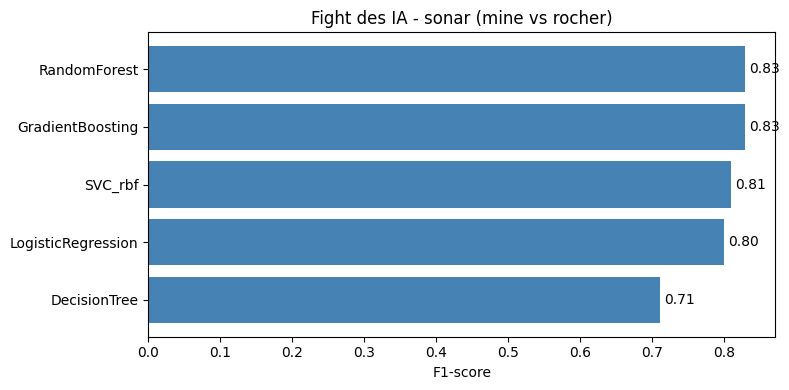

In [14]:
noms = [r[0] for r in leaderboard]
scores = [r[1] for r in leaderboard]
plt.figure(figsize=(8, 4))
plt.barh(noms[::-1], scores[::-1], color="steelblue")
plt.xlabel("F1-score")
plt.title("Fight des IA - sonar (mine vs rocher)")
for i, s in enumerate(scores[::-1]):
    plt.text(s + 0.005, i, f"{s:.2f}", va="center")
plt.tight_layout()
plt.show()

---
### Bilan du Fight

- **Regression (Phase A)** : le Random Forest ecrase la regression lineaire (R2 ~0.80 vs ~0.58),
  mais la lineaire reste lisible et auditable.
- **Clustering (Phase B)** : 2 segments ressortent (meilleure silhouette) ; le scaling
  est obligatoire avant KMeans, et un seul outlier non nettoye casse les clusters.
- **Spam (Phase C)** : Naive Bayes et la regression logistique attrapent l'essentiel des spams ;
  on juge sur precision/recall/f1, pas sur l'accuracy (classes desequilibrees).
- **Sonar (Phase D/E)** : sur F1 et accuracy, le **Random Forest** et le **Gradient Boosting**
  sont au coude a coude en tete, le SVM rbf juste derriere. MAIS le champion depend de la
  metrique : en **recall** (reperer un maximum de mines, ce qui compte vraiment pour un
  sous-marin), c'est la **regression logistique** qui gagne. Et une fois **tune**, le SVM
  rbf passe de 0.81 a 0.86 en F1 : ne jamais juger un algo sur un seul reglage.

Mon choix : pour ce probleme ou rater une mine est dramatique, je privilegie le **recall**,
donc la regression logistique (en plus rapide et explicable). Le reflexe a graver : meme
split, meme metrique adaptee au probleme, et un champion justifie au-dela du score brut
(temps, interpretabilite, robustesse).